# Movie Industry Analysis (TMDB 5000 Movie Dataset)

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project analyses movie data from TMDB (The Movie Database). It investigates how budget, runtime, release date, and genre affect revenue and audience ratings. The insights help answer questions like: Which genres are most profitable? Is there a correlation between budget and revenue? Which months are best for release? The notebook includes 10 publication‑ready visualisations.

## Dataset
- **Source:** Kaggle – TMDB 5000 Movie Dataset
- **Rows:** 4,803 movies
- **Columns:** budget, revenue, vote_average, vote_count, popularity, genres, release_date, runtime, original_language, production_companies

## Key Steps
1. Data cleaning (handle missing values, convert date)
2. Feature engineering (profit, profit margin, release month)
3. Explore relationships between numerical variables
4. Analyse genre performance
5. Visualise trends and distributions

## Requirements
- pandas, matplotlib, seaborn, numpy, ast (for parsing genres)

---

**© 2026 Ibrahim – Movie industry analytics.**

### Install & Imports

In [1]:
!pip install -q pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

In [4]:
from google.colab import files

print("Please upload the 'tmdb_5000_movies.csv' file you downloaded from Kaggle.")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset shape:", df.shape)
df.head(2)

Please upload the 'tmdb_5000_movies.csv' file you downloaded from Kaggle.


Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv
Dataset shape: (4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


### Data Cleaning

In [5]:
# Drop rows with zero budget or zero revenue (cannot compute profit)
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

# Create profit and profit margin columns
df['profit'] = df['revenue'] - df['budget']
df['profit_margin'] = (df['profit'] / df['budget']) * 100

# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_month'] = df['release_date'].dt.month
df['release_year'] = df['release_date'].dt.year

print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 3229


### Budget vs Revenue Scatter (coloured by profit margin)

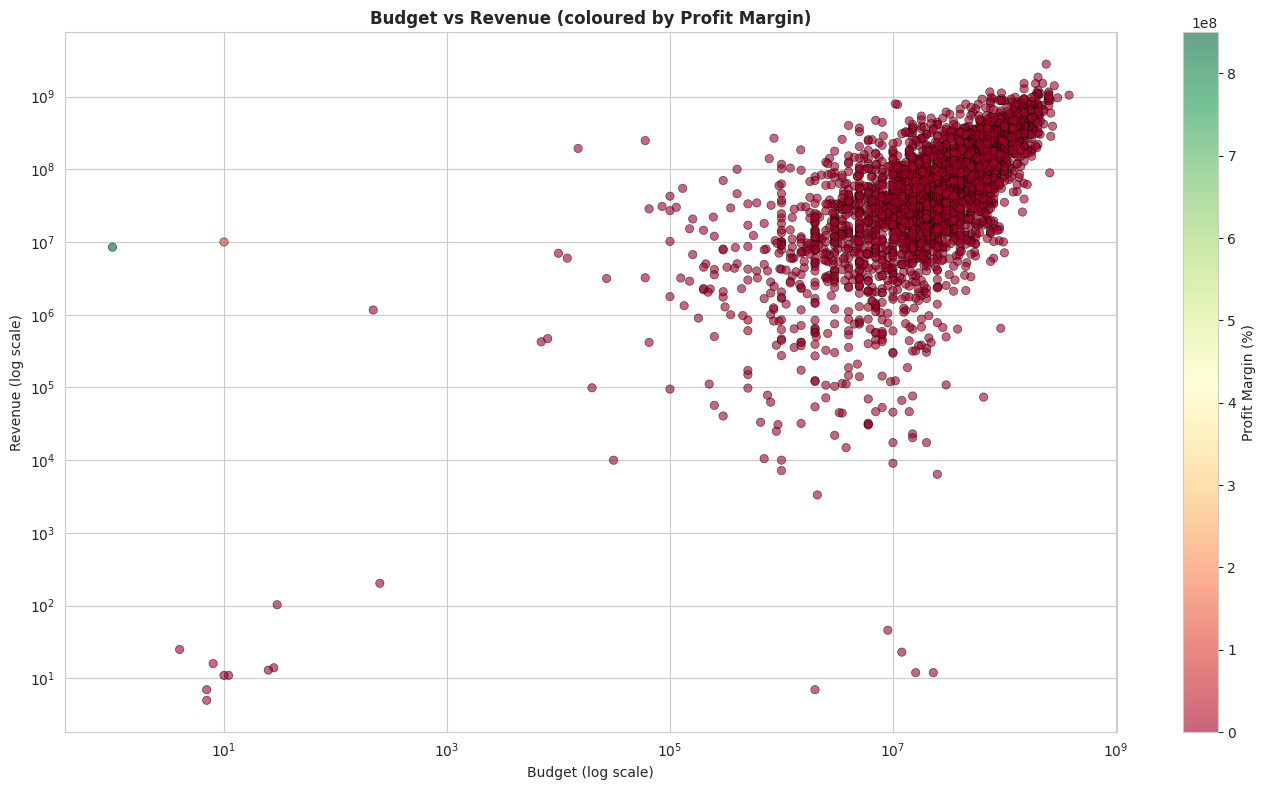

In [6]:
plt.figure(figsize=(14, 8))
scatter = plt.scatter(df['budget'], df['revenue'], c=df['profit_margin'], cmap='RdYlGn', alpha=0.6, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Profit Margin (%)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Budget (log scale)')
plt.ylabel('Revenue (log scale)')
plt.title('Budget vs Revenue (coloured by Profit Margin)', fontweight='bold')
plt.tight_layout()
plt.show()

### Top 10 Most Profitable Movies

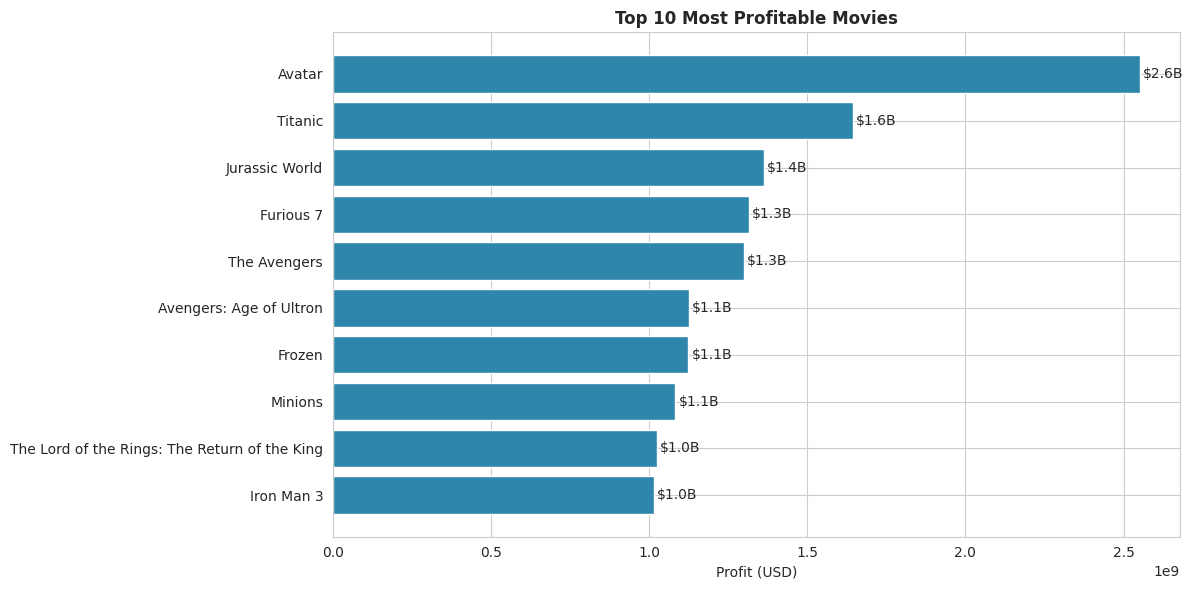

In [7]:
top_profit = df.nlargest(10, 'profit')[['original_title', 'profit']]

plt.figure(figsize=(12, 6))
bars = plt.barh(top_profit['original_title'][::-1], top_profit['profit'][::-1], color='#2E86AB')
plt.xlabel('Profit (USD)')
plt.title('Top 10 Most Profitable Movies', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1e7, bar.get_y() + bar.get_height()/2, f'${width/1e9:.1f}B', va='center')
plt.tight_layout()
plt.show()

### Average Revenue by Genre

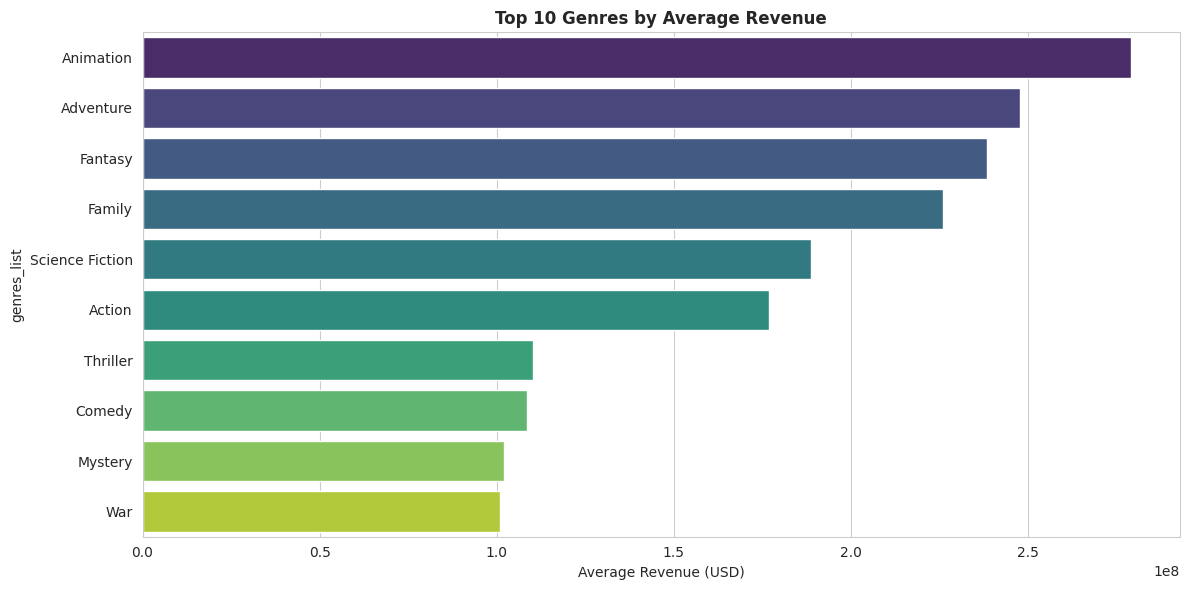

In [8]:
# Parse genres (stored as JSON-like string)
def parse_genres(genre_str):
    try:
        genre_list = ast.literal_eval(genre_str)
        return [g['name'] for g in genre_list]
    except:
        return []

df['genres_list'] = df['genres'].apply(parse_genres)
df_expanded = df.explode('genres_list')

genre_revenue = df_expanded.groupby('genres_list')['revenue'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_revenue.values, y=genre_revenue.index, palette='viridis')
plt.xlabel('Average Revenue (USD)')
plt.title('Top 10 Genres by Average Revenue', fontweight='bold')
plt.tight_layout()
plt.show()

### Vote Average Distribution

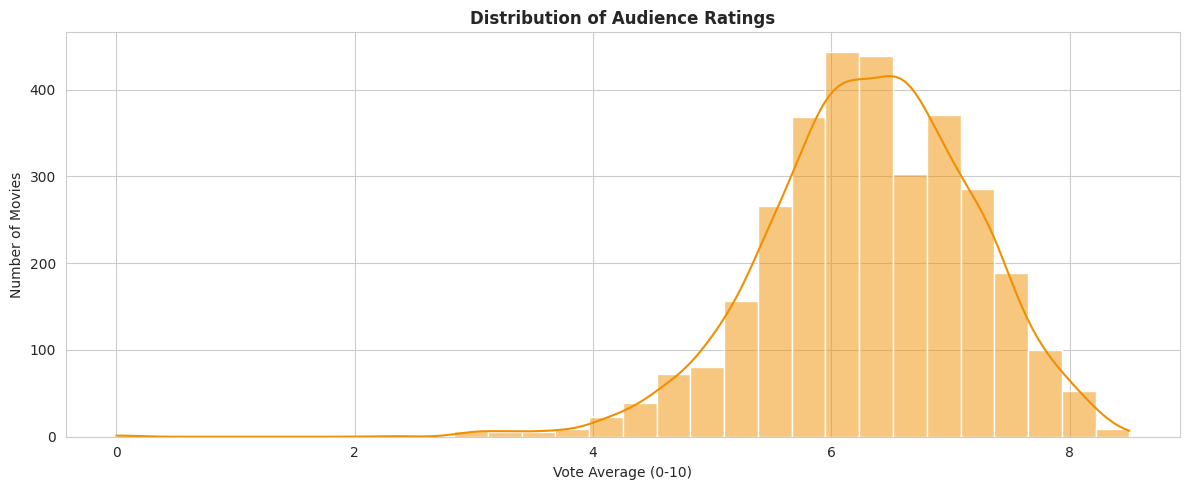

In [9]:
plt.figure(figsize=(12, 5))
sns.histplot(df['vote_average'], bins=30, kde=True, color='#F18F01')
plt.xlabel('Vote Average (0-10)')
plt.ylabel('Number of Movies')
plt.title('Distribution of Audience Ratings', fontweight='bold')
plt.tight_layout()
plt.show()

### Average Revenue by Release Month

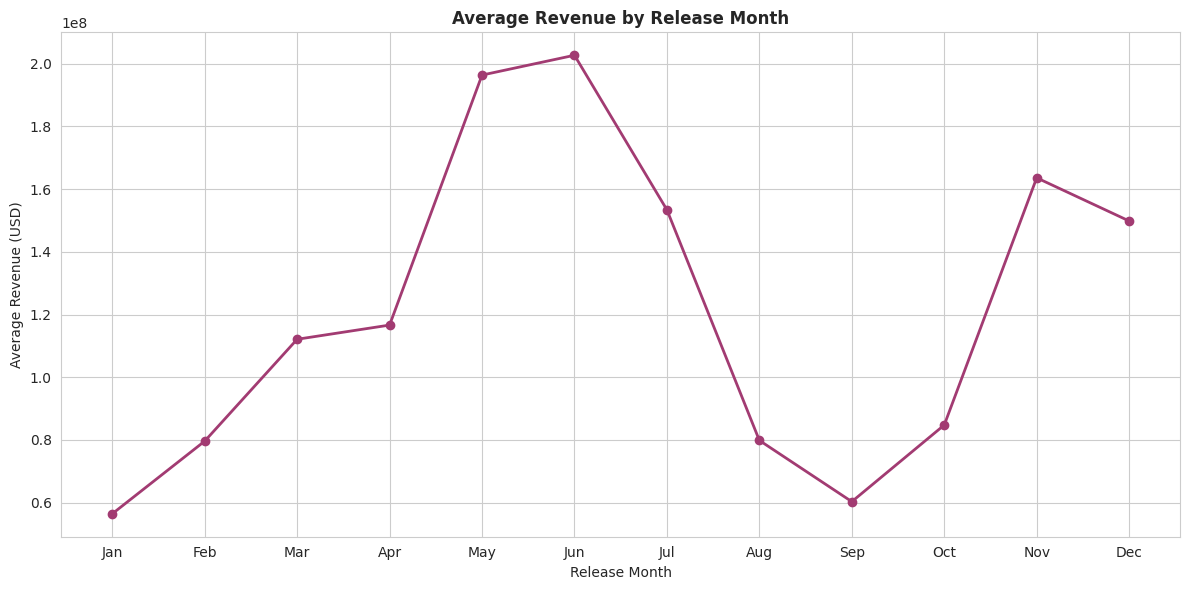

In [10]:
monthly_revenue = df.groupby('release_month')['revenue'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
plt.plot(range(1,13), monthly_revenue.values, marker='o', linewidth=2, color='#A23B72')
plt.xticks(range(1,13), month_names)
plt.xlabel('Release Month')
plt.ylabel('Average Revenue (USD)')
plt.title('Average Revenue by Release Month', fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

### Correlation Heatmap

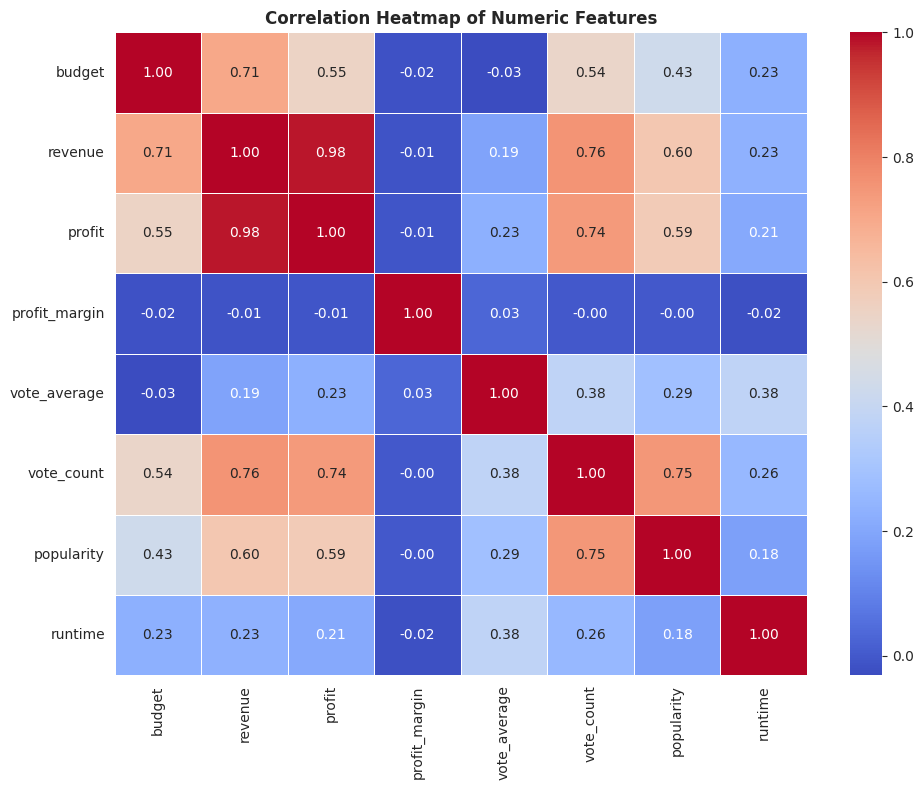

In [11]:
numeric_cols = ['budget', 'revenue', 'profit', 'profit_margin', 'vote_average', 'vote_count', 'popularity', 'runtime']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

### Top 10 Production Companies by Total Revenue

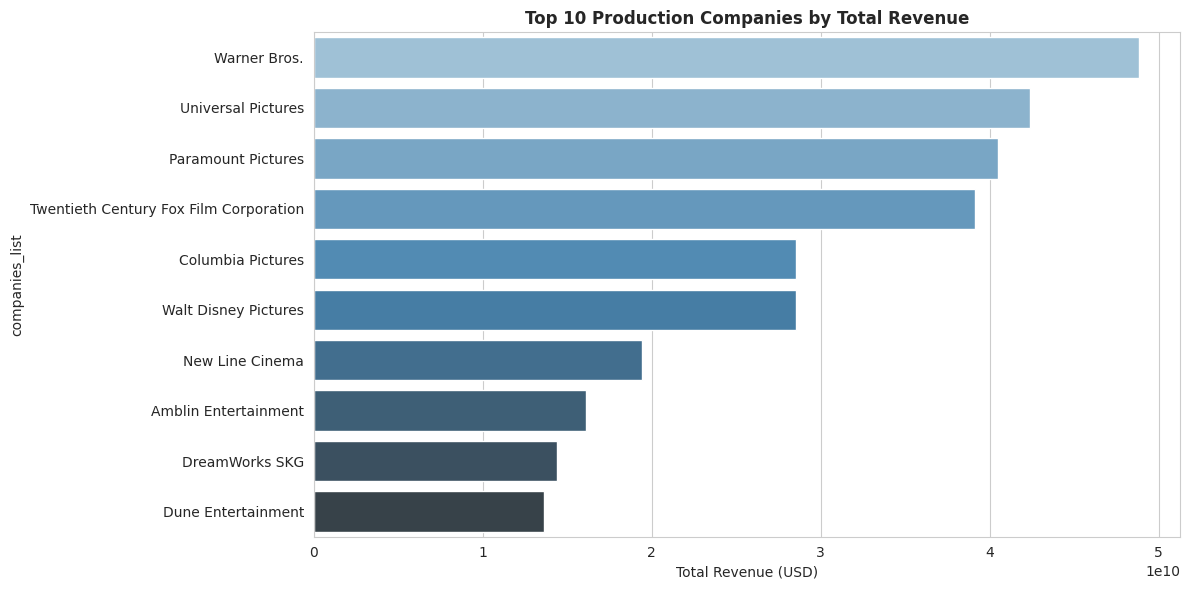

In [12]:
# Parse production companies
def parse_companies(comp_str):
    try:
        comp_list = ast.literal_eval(comp_str)
        return [c['name'] for c in comp_list]
    except:
        return []

df['companies_list'] = df['production_companies'].apply(parse_companies)
df_comp_expanded = df.explode('companies_list')
company_revenue = df_comp_expanded.groupby('companies_list')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=company_revenue.values, y=company_revenue.index, palette='Blues_d')
plt.xlabel('Total Revenue (USD)')
plt.title('Top 10 Production Companies by Total Revenue', fontweight='bold')
plt.tight_layout()
plt.show()

### Runtime vs Revenue Scatter

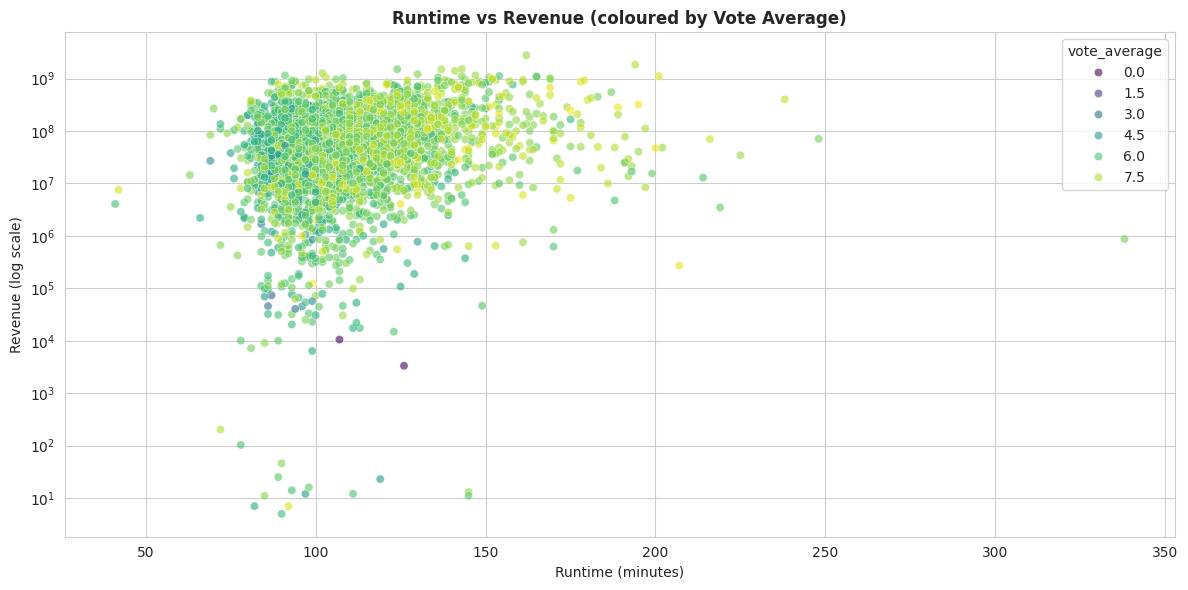

In [13]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='runtime', y='revenue', alpha=0.6, hue='vote_average', palette='viridis')
plt.yscale('log')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Revenue (log scale)')
plt.title('Runtime vs Revenue (coloured by Vote Average)', fontweight='bold')
plt.tight_layout()
plt.show()

### Number of Movies per Genre (Genre Popularity)

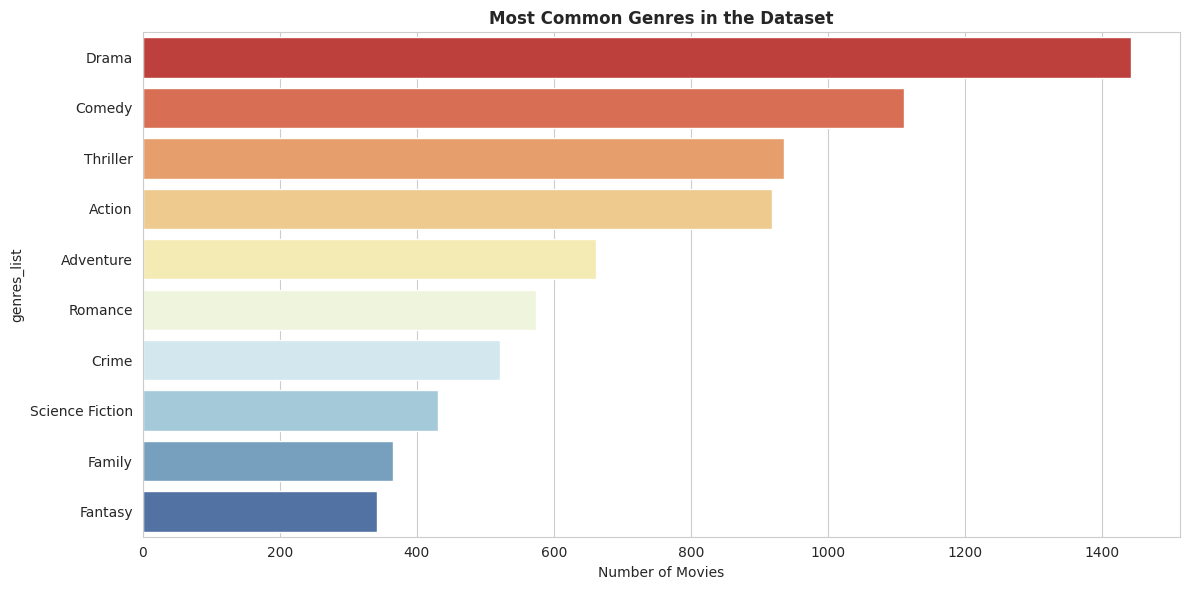

In [14]:
genre_count = df_expanded['genres_list'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_count.values, y=genre_count.index, palette='RdYlBu')
plt.xlabel('Number of Movies')
plt.title('Most Common Genres in the Dataset', fontweight='bold')
plt.tight_layout()
plt.show()

### Profit Margin Box Plot by Genre (Top 8)

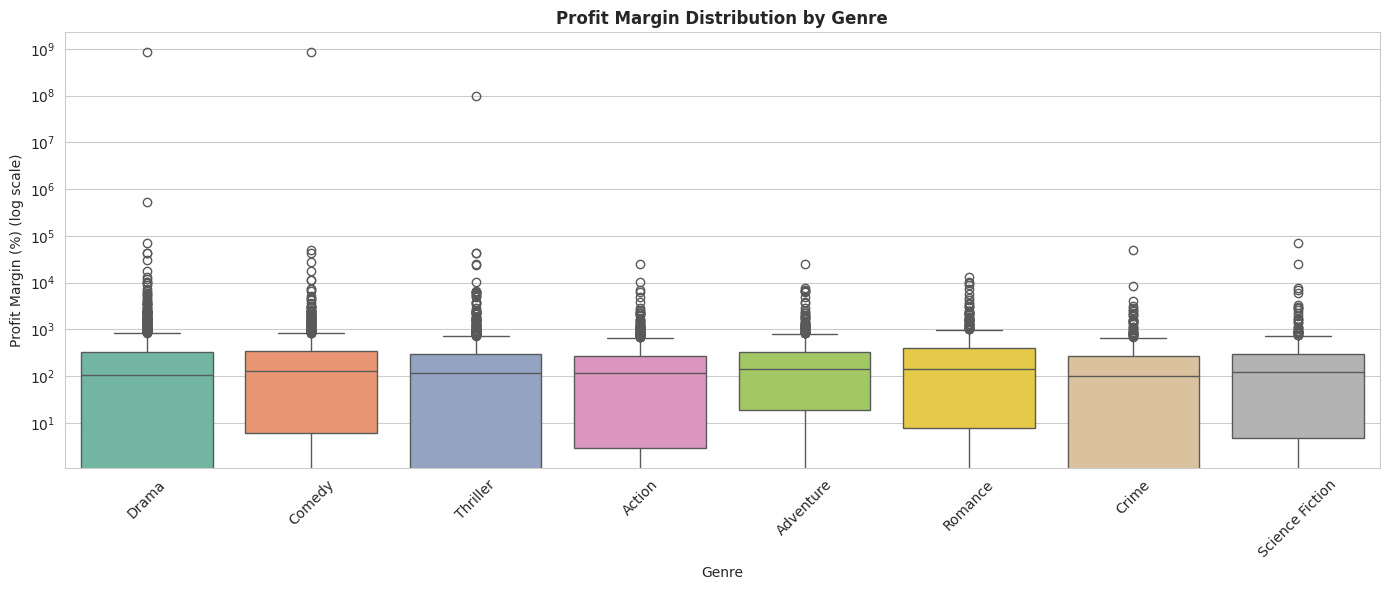

In [15]:
# Select top 8 genres by number of movies
top_genres = genre_count.head(8).index
genre_profit = df_expanded[df_expanded['genres_list'].isin(top_genres)]
plt.figure(figsize=(14, 6))
sns.boxplot(data=genre_profit, x='genres_list', y='profit_margin', order=top_genres, palette='Set2')
plt.yscale('log')
plt.xlabel('Genre')
plt.ylabel('Profit Margin (%) (log scale)')
plt.title('Profit Margin Distribution by Genre', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Insights Summary

In [16]:
print(" Key Insights from Movie Industry Analysis")
print(f" Total movies analysed: {len(df)}")
print(f" Most profitable movie: {top_profit.iloc[0]['original_title']} (${top_profit.iloc[0]['profit']/1e9:.2f}B profit)")
print(f" Genre with highest avg revenue: {genre_revenue.index[0]}")
print(f" Best release month (avg revenue): {month_names[monthly_revenue.idxmax()-1]}")
print(f" Correlation between budget and revenue: {df['budget'].corr(df['revenue']):.2f}")
print(" Insights for production studios and marketers.")

 Key Insights from Movie Industry Analysis
 Total movies analysed: 3229
 Most profitable movie: Avatar ($2.55B profit)
 Genre with highest avg revenue: Animation
 Best release month (avg revenue): Jun
 Correlation between budget and revenue: 0.71
 Insights for production studios and marketers.


### Final Summary

In [17]:
print("Movie Industry Analysis - COMPLETED")
print("Author: Ibrahim")
print("Dataset cleaned and explored.")
print("Relationships between budget, revenue, genre, and runtime visualised.")
print("Top profitable movies and genres identified.")
print("Ready for strategic recommendations.")

Movie Industry Analysis - COMPLETED
Author: Ibrahim
Dataset cleaned and explored.
Relationships between budget, revenue, genre, and runtime visualised.
Top profitable movies and genres identified.
Ready for strategic recommendations.
